In [ ]:
# split_components.py
# Run this from inside your Downloads/Components folder

import os
import shutil
import random

src = r"D:\Downloads\Components"  # change this path
dst = r"D:\Downloads\Components_split"  # output folder

splits = {"train": 0.70, "val": 0.15, "test": 0.15}

for class_name in os.listdir(src):
    class_path = os.path.join(src, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    random.shuffle(images)

    n = len(images)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)

    split_data = {
        "train": images[:n_train],
        "val":   images[n_train:n_train + n_val],
        "test":  images[n_train + n_val:]
    }

    for split, files in split_data.items():
        out_dir = os.path.join(dst, split, class_name)
        os.makedirs(out_dir, exist_ok=True)
        for f in files:
            shutil.copy2(os.path.join(class_path, f), os.path.join(out_dir, f))
        print(f"{split}/{class_name}: {len(files)} images")

print("\nComponents split done!")

train/armature: 224 images
val/armature: 48 images
test/armature: 49 images
train/attenuator: 189 images
val/attenuator: 40 images
test/attenuator: 42 images
train/Bypass-capacitor: 211 images
val/Bypass-capacitor: 45 images
test/Bypass-capacitor: 46 images
train/cartridge-fuse: 157 images
val/cartridge-fuse: 33 images
test/cartridge-fuse: 35 images
train/clip-lead: 201 images
val/clip-lead: 43 images
test/clip-lead: 44 images
train/electric-relay: 294 images
val/electric-relay: 63 images
test/electric-relay: 63 images
train/Electrolytic-capacitor: 282 images
val/Electrolytic-capacitor: 60 images
test/Electrolytic-capacitor: 61 images
train/filament: 280 images
val/filament: 60 images
test/filament: 60 images
train/heat-sink: 294 images
val/heat-sink: 63 images
test/heat-sink: 63 images
train/images: 0 images
val/images: 0 images
test/images: 0 images
train/induction-coil: 105 images
val/induction-coil: 22 images
test/induction-coil: 24 images
train/Integrated-micro-circuit: 329 images

In [5]:
# fix_wastes_val.py
# Run this FIRST, before merge_datasets.py

import os
import shutil
import random

wastes_train = r"D:\Downloads\Wastes\train"  # update path
wastes_val   = r"D:\Downloads\Wastes\val"    # will be created

random.seed(42)  # ensures reproducibility

for class_name in os.listdir(wastes_train):
    class_path = os.path.join(wastes_train, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]

    random.shuffle(images)

    # Take 15% from train → move to val
    n_val = max(1, int(len(images) * 0.15))
    val_images = images[:n_val]

    val_class_dir = os.path.join(wastes_val, class_name)
    os.makedirs(val_class_dir, exist_ok=True)

    for img in val_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(val_class_dir, img)
        shutil.move(src, dst)  # moves out of train into val

    print(f"{class_name}: moved {n_val} images to val, {len(images)-n_val} remain in train")

print("\nWastes val folder created successfully!")

battery waste: moved 127 images to val, 721 remain in train
e-waste: moved 187 images to val, 1061 remain in train
light bulbs: moved 63 images to val, 357 remain in train

Wastes val folder created successfully!


In [6]:
# verify_current.py
import os

master = r"D:\Downloads\MASTER_DATASET"  # update path

print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Status")
print("-" * 75)

total_train = total_val = total_test = 0

train_path = os.path.join(master, "train")
if not os.path.exists(train_path):
    print("MASTER_DATASET train folder not found — check path")
    exit()

classes = sorted(os.listdir(train_path))

for cls in classes:
    counts = {}
    for split in ["train", "val", "test"]:
        p = os.path.join(master, split, cls)
        counts[split] = len([
            f for f in os.listdir(p)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
        ]) if os.path.exists(p) else 0

    total_train += counts["train"]
    total_val   += counts["val"]
    total_test  += counts["test"]

    if counts["train"] == 0:
        status = "❌ EMPTY — delete"
    elif counts["train"] < 100:
        status = "🔴 CRITICAL — drop"
    elif counts["train"] < 200:
        status = "🟡 LOW — augment"
    elif counts["train"] < 300:
        status = "🟠 ACCEPTABLE"
    else:
        status = "🟢 GOOD"

    print(f"{cls:<35} {counts['train']:>7} {counts['val']:>7} "
          f"{counts['test']:>7}  {status}")

print("-" * 75)
print(f"{'TOTAL':<35} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"\nTotal classes : {len(classes)}")
print(f"Total images  : {total_train + total_val + total_test}")


Class                                 Train     Val    Test  Status
---------------------------------------------------------------------------
Battery                                 961     157     243  🟢 GOOD
Bypass-capacitor                        211      45      46  🟠 ACCEPTABLE
Electrolytic-capacitor                  282      60      61  🟠 ACCEPTABLE
Integrated-micro-circuit                329      70      71  🟢 GOOD
Keyboard                                240      30      30  🟠 ACCEPTABLE
LED                                     336      72      72  🟢 GOOD
Microwave                               240      30      30  🟠 ACCEPTABLE
Mobile                                  240      30      30  🟠 ACCEPTABLE
Mouse                                   240      30      30  🟠 ACCEPTABLE
PCB                                     240      30      30  🟠 ACCEPTABLE
PNP-transistor                          214      46      47  🟠 ACCEPTABLE
Player                                  240      30      30

In [7]:
# step1_drop_classes.py
import os, shutil

master = r"D:\Downloads\MASTER_DATASET"

DROP = [
    "light-circuit",
    "local-oscillator", 
    "multiplexer",
    "omni-directional-antenna",
    "shunt",
    "images"
]

for split in ["train", "val", "test"]:
    for cls in DROP:
        path = os.path.join(master, split, cls)
        if os.path.exists(path):
            shutil.rmtree(path)
            print(f"Deleted: {split}/{cls}")

print("\nDone — critical classes removed!")

Deleted: train/light-circuit
Deleted: train/local-oscillator
Deleted: train/multiplexer
Deleted: train/omni-directional-antenna
Deleted: train/shunt
Deleted: train/images
Deleted: val/light-circuit
Deleted: val/local-oscillator
Deleted: val/multiplexer
Deleted: val/omni-directional-antenna
Deleted: val/shunt
Deleted: val/images
Deleted: test/light-circuit
Deleted: test/local-oscillator
Deleted: test/multiplexer
Deleted: test/omni-directional-antenna
Deleted: test/shunt
Deleted: test/images

Done — critical classes removed!


In [5]:
# step2_augment.py — FIXED for albumentations >= 1.4
import os, cv2, random
import albumentations as A

master = r"D:\Downloads\MASTER_DATASET"

TARGETS = {
    # 🟡 LOW — boost to 300
    "attenuator":          300,
    "cartridge-fuse":      300,
    "induction-coil":      300,
    "jumper-cable":        300,
    "potential-divider":   300,
    "rheostat":            300,
    "stabilizer":          300,
    "step-up-transformer": 300,
    "transistor":          300,
    # 🟠 ACCEPTABLE — mild boost to 280
    "Bypass-capacitor":    280,
    "PNP-transistor":      280,
    "armature":            280,
    "clip-lead":           280,
    "memory-chip":         280,
}

strong_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3, p=0.5),
    A.GaussNoise(p=0.3),
    A.ElasticTransform(p=0.2),
    A.RandomResizedCrop(
        size=(224, 224),        # ← FIXED
        scale=(0.75, 1.0), p=0.5),
])

mild_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2, p=0.4),
    A.RandomResizedCrop(
        size=(224, 224),        # ← FIXED
        scale=(0.85, 1.0), p=0.3),
])

for cls, target in TARGETS.items():
    train_path = os.path.join(master, "train", cls)
    if not os.path.exists(train_path):
        print(f"Skipping {cls} — folder not found")
        continue

    images = [f for f in os.listdir(train_path)
              if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]

    current = len(images)
    needed  = max(0, target - current)

    if needed == 0:
        print(f"{cls}: already at {current}, skipping")
        continue

    is_low    = current < 200
    transform = strong_transform if is_low else mild_transform

    print(f"{cls}: {current} → generating {needed} images...")

    aug_count = 0
    while aug_count < needed:
        src_file = random.choice(images)
        src_path = os.path.join(train_path, src_file)
        img = cv2.imread(src_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = transform(image=img)["image"]
        augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        out_name  = f"aug_{aug_count:04d}_{src_file}"
        cv2.imwrite(os.path.join(train_path, out_name), augmented)
        aug_count += 1

    print(f"  Done — {cls} now has {current + aug_count} train images")

print("\nAugmentation complete!")

attenuator: 189 → generating 111 images...
  Done — attenuator now has 300 train images
cartridge-fuse: 157 → generating 143 images...
  Done — cartridge-fuse now has 300 train images
induction-coil: 105 → generating 195 images...
  Done — induction-coil now has 300 train images
jumper-cable: 174 → generating 126 images...
  Done — jumper-cable now has 300 train images
potential-divider: 165 → generating 135 images...
  Done — potential-divider now has 300 train images
rheostat: 118 → generating 182 images...
  Done — rheostat now has 300 train images
stabilizer: 113 → generating 187 images...
  Done — stabilizer now has 300 train images
step-up-transformer: 108 → generating 192 images...
  Done — step-up-transformer now has 300 train images
transistor: 107 → generating 193 images...
  Done — transistor now has 300 train images
Bypass-capacitor: 211 → generating 69 images...
  Done — Bypass-capacitor now has 280 train images
PNP-transistor: 214 → generating 66 images...
  Done — PNP-tr

In [10]:
# step3_final_verify.py
import os

master = r"D:\Downloads\MASTER_DATASET"

print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Status")
print("-" * 75)

total_train = total_val = total_test = 0
classes = sorted(os.listdir(os.path.join(master, "train")))

for cls in classes:
    counts = {}
    for split in ["train", "val", "test"]:
        p = os.path.join(master, split, cls)
        counts[split] = len([
            f for f in os.listdir(p)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
        ]) if os.path.exists(p) else 0

    total_train += counts["train"]
    total_val   += counts["val"]
    total_test  += counts["test"]

    if counts["train"] == 0:
        status = "❌ EMPTY"
    elif counts["train"] < 200:
        status = "🟡 LOW"
    elif counts["train"] < 300:
        status = "🟠 ACCEPTABLE"
    else:
        status = "🟢 GOOD"

    print(f"{cls:<35} {counts['train']:>7} {counts['val']:>7} "
          f"{counts['test']:>7}  {status}")

print("-" * 75)
print(f"{'TOTAL':<35} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"\nFinal classes : {len(classes)}")
print(f"Final images  : {total_train + total_val + total_test}")


Class                                 Train     Val    Test  Status
---------------------------------------------------------------------------
Battery                                 961     237     163  🟢 GOOD
Capacitor                               444      95      96  🟢 GOOD
Integrated-micro-circuit               1381     295     297  🟢 GOOD
Keyboard                                240      30      30  🟠 ACCEPTABLE
LED                                     406      87      87  🟢 GOOD
Microwave                               240      30      30  🟠 ACCEPTABLE
Mobile                                  240      30      30  🟠 ACCEPTABLE
Mouse                                   240      30      30  🟠 ACCEPTABLE
PCB                                     240      30      30  🟠 ACCEPTABLE
PNP-transistor                          280      46      47  🟠 ACCEPTABLE
Player                                  240      30      30  🟠 ACCEPTABLE
Printer                                 240      30      30  🟠 AC

In [8]:
# fix_val_gap.py
import os, shutil, random

master = r"D:\Downloads\MASTER_DATASET"

# Move excess test images → val to balance them
FIX_CLASSES = {
    "Battery":     80,   # move 80 from test → val
    "light bulbs": 30,   # move 30 from test → val
}

random.seed(42)

for cls, move_count in FIX_CLASSES.items():
    test_path = os.path.join(master, "test", cls)
    val_path  = os.path.join(master, "val",  cls)
    os.makedirs(val_path, exist_ok=True)

    test_images = [f for f in os.listdir(test_path)
                   if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]

    random.shuffle(test_images)
    to_move = test_images[:move_count]

    for img in to_move:
        shutil.move(
            os.path.join(test_path, img),
            os.path.join(val_path,  img)
        )

    print(f"{cls}: moved {move_count} images from test → val")

print("\nDone!")

Battery: moved 80 images from test → val
light bulbs: moved 30 images from test → val

Done!


In [9]:
# add_new_datasets.py
import os, shutil, random, cv2

random.seed(42)

MASTER      = r"D:\Downloads\MASTER_DATASET"
DATASET1    = r"D:\Downloads\dataset"
DATASET2    = r"D:\Downloads\dataset2"

# ── Step 1: Drop old capacitor classes from MASTER ──────────────
DROP_FROM_MASTER = ["Bypass-capacitor", "Electrolytic-capacitor"]

print("── Step 1: Removing old capacitor classes ──")
for cls in DROP_FROM_MASTER:
    for split in ["train", "val", "test"]:
        path = os.path.join(MASTER, split, cls)
        if os.path.exists(path):
            shutil.rmtree(path)
            print(f"  Deleted: {split}/{cls}")

# ── Step 2: Define class mapping ─────────────────────────────────
# Format: { "source_folder_name": "target_class_name_in_MASTER" }

DATASET1_MAP = {
    "Transistors":  "transistor",
    "Resistors":    "Resistor",
    "LEDs":         "LED",
    "Chips":        "microchip",
    "Capacitors":   "Capacitor",
}

DATASET2_MAP = {
    "Transformer":  "step-down-transformer",
    "Resistor":     "Resistor",
    "Inductor":     "induction-coil",
    "IC":           "Integrated-micro-circuit",
    "Diode":        "semiconductor-diode",
    "Capacitor":    "Capacitor",
}

SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}

def split_and_merge(src_root, class_map, dataset_name):
    print(f"\n── Processing {dataset_name} ──")
    for src_folder, target_class in class_map.items():
        src_path = os.path.join(src_root, src_folder)
        if not os.path.exists(src_path):
            print(f"  Skipping {src_folder} — folder not found")
            continue

        images = [f for f in os.listdir(src_path)
                  if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
        random.shuffle(images)

        n       = len(images)
        n_train = int(n * 0.70)
        n_val   = int(n * 0.15)

        split_data = {
            "train": images[:n_train],
            "val":   images[n_train:n_train + n_val],
            "test":  images[n_train + n_val:]
        }

        for split, files in split_data.items():
            dst_dir = os.path.join(MASTER, split, target_class)
            os.makedirs(dst_dir, exist_ok=True)
            for f in files:
                src_img = os.path.join(src_path, f)
                dst_img = os.path.join(dst_dir, f"{dataset_name}_{f}")
                shutil.copy2(src_img, dst_img)

        print(f"  {src_folder} → {target_class}: "
              f"{split_data['train'].__len__()} train | "
              f"{split_data['val'].__len__()} val | "
              f"{split_data['test'].__len__()} test")

# ── Step 3: Run merge for both datasets ──────────────────────────
split_and_merge(DATASET1, DATASET1_MAP, "ds1")
split_and_merge(DATASET2, DATASET2_MAP, "ds2")

# ── Step 4: Final count report ───────────────────────────────────
print(f"\n── Final Dataset Summary ──")
print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Status")
print("-" * 75)

total_train = total_val = total_test = 0
classes = sorted(os.listdir(os.path.join(MASTER, "train")))

for cls in classes:
    counts = {}
    for split in ["train", "val", "test"]:
        p = os.path.join(MASTER, split, cls)
        counts[split] = len([
            f for f in os.listdir(p)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
        ]) if os.path.exists(p) else 0

    total_train += counts["train"]
    total_val   += counts["val"]
    total_test  += counts["test"]

    if counts["train"] == 0:
        status = "❌ EMPTY"
    elif counts["train"] < 200:
        status = "🟡 LOW"
    elif counts["train"] < 300:
        status = "🟠 ACCEPTABLE"
    else:
        status = "🟢 GOOD"

    print(f"{cls:<35} {counts['train']:>7} {counts['val']:>7} "
          f"{counts['test']:>7}  {status}")

print("-" * 75)
print(f"{'TOTAL':<35} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"\nFinal classes : {len(classes)}")
print(f"Final images  : {total_train + total_val + total_test}")


── Step 1: Removing old capacitor classes ──
  Deleted: train/Bypass-capacitor
  Deleted: val/Bypass-capacitor
  Deleted: test/Bypass-capacitor
  Deleted: train/Electrolytic-capacitor
  Deleted: val/Electrolytic-capacitor
  Deleted: test/Electrolytic-capacitor

── Processing ds1 ──
  Transistors → transistor: 70 train | 15 val | 15 test
  Resistors → Resistor: 67 train | 14 val | 16 test
  LEDs → LED: 70 train | 15 val | 15 test
  Chips → microchip: 70 train | 15 val | 15 test
  Capacitors → Capacitor: 70 train | 15 val | 15 test

── Processing ds2 ──
  Transformer → step-down-transformer: 522 train | 112 val | 113 test
  Resistor → Resistor: 329 train | 70 val | 71 test
  Inductor → induction-coil: 185 train | 39 val | 41 test
  IC → Integrated-micro-circuit: 1052 train | 225 val | 226 test
  Diode → semiconductor-diode: 362 train | 77 val | 79 test
  Capacitor → Capacitor: 374 train | 80 val | 81 test

── Final Dataset Summary ──

Class                                 Train     Val  

In [11]:
# boost_acceptable_classes.py
import os, cv2, random
import albumentations as A

MASTER = r"D:\Downloads\MASTER_DATASET"
TARGET = 400

random.seed(42)

BOOST_CLASSES = [
    # 240 → 400
    "Keyboard", "Microwave", "Mobile", "Mouse", "PCB",
    "Player", "Printer", "Television", "Washing Machine",
    # 280–298 → 400
    "PNP-transistor", "armature", "clip-lead", "electric-relay",
    "filament", "heat-sink", "limiter-clipper", "memory-chip",
    "semi-conductor",
    # 221 → 400
    "pulse-generator", "solenoid",
]

strong_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3, p=0.5),
    A.GaussNoise(p=0.3),
    A.ElasticTransform(p=0.2),
    A.RandomResizedCrop(
        size=(224, 224),
        scale=(0.75, 1.0), p=0.5),
])

mild_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2, p=0.4),
    A.RandomResizedCrop(
        size=(224, 224),
        scale=(0.85, 1.0), p=0.3),
])

print(f"{'Class':<30} {'Before':>8} {'Added':>8} {'After':>8}")
print("-" * 60)

for cls in BOOST_CLASSES:
    train_path = os.path.join(MASTER, "train", cls)
    if not os.path.exists(train_path):
        print(f"{cls:<30} NOT FOUND — skipping")
        continue

    images = [f for f in os.listdir(train_path)
              if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]

    current = len(images)
    needed  = max(0, TARGET - current)

    if needed == 0:
        print(f"{cls:<30} {current:>8} {'—':>8} {current:>8}  already OK")
        continue

    # Strong transform for 240 classes, mild for 280+ classes
    transform = strong_transform if current <= 250 else mild_transform

    aug_count = 0
    while aug_count < needed:
        src_file = random.choice(images)
        src_path = os.path.join(train_path, src_file)
        img = cv2.imread(src_path)
        if img is None:
            continue
        img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = transform(image=img)["image"]
        augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        out_name  = f"aug_{aug_count:04d}_{src_file}"
        cv2.imwrite(os.path.join(train_path, out_name), augmented)
        aug_count += 1

    print(f"{cls:<30} {current:>8} {aug_count:>8} {current+aug_count:>8}")

print("-" * 60)
print("\nAugmentation complete — run verify script to confirm.")

Class                            Before    Added    After
------------------------------------------------------------
Keyboard                            240      160      400
Microwave                           240      160      400
Mobile                              240      160      400
Mouse                               240      160      400
PCB                                 240      160      400
Player                              240      160      400
Printer                             240      160      400
Television                          240      160      400
Washing Machine                     240      160      400
PNP-transistor                      280      120      400
armature                            280      120      400
clip-lead                           280      120      400
electric-relay                      294      106      400
filament                            280      120      400
heat-sink                           294      106      400
limiter-cli

In [11]:
# final_verify.py
import os

MASTER = r"D:\Downloads\MASTER_DATASET"

print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Status")
print("-" * 75)

total_train = total_val = total_test = 0
classes = sorted(os.listdir(os.path.join(MASTER, "train")))

for cls in classes:
    counts = {}
    for split in ["train", "val", "test"]:
        p = os.path.join(MASTER, split, cls)
        counts[split] = len([
            f for f in os.listdir(p)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
        ]) if os.path.exists(p) else 0

    total_train += counts["train"]
    total_val   += counts["val"]
    total_test  += counts["test"]

    if counts["train"] < 300:
        status = "🟡 LOW"
    elif counts["train"] < 400:
        status = "🟠 ACCEPTABLE"
    else:
        status = "🟢 GOOD"

    print(f"{cls:<35} {counts['train']:>7} {counts['val']:>7} "
          f"{counts['test']:>7}  {status}")

print("-" * 75)
print(f"{'TOTAL':<35} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"\nFinal classes : {len(classes)}")
print(f"Final images  : {total_train + total_val + total_test}")


Class                                 Train     Val    Test  Status
---------------------------------------------------------------------------
Battery                                 961     237     163  🟢 GOOD
Capacitor                               444      95      96  🟢 GOOD
Integrated-micro-circuit               1381     295     297  🟢 GOOD
Keyboard                               1099     179     181  🟢 GOOD
LED                                     406      87      87  🟢 GOOD
Microwave                               400      30      30  🟢 GOOD
Mobile                                  400      30      30  🟢 GOOD
Mouse                                   400      30      30  🟢 GOOD
PCB                                     703      94      96  🟢 GOOD
Player                                  400      30      30  🟢 GOOD
Printer                                 400      30      30  🟢 GOOD
Resistor                                396      84      87  🟠 ACCEPTABLE
Television                       

In [1]:
# path_a_cleanup.py
import os, shutil

MASTER = r"D:\Downloads\MASTER_DATASET"

KEEP = {
    "Battery", "PCB", "Mobile", "Television", "Microwave",
    "Washing Machine", "Printer", "Keyboard", "Mouse", "Player",
    "light bulbs", "Capacitor", "LED", "Resistor",
    "Integrated-micro-circuit", "semiconductor-diode", "transistor",
    "microchip", "microprocessor", "heat-sink"
}

print("── Dropping non-e-waste classes ──")
dropped = []

for split in ["train", "val", "test"]:
    split_path = os.path.join(MASTER, split)
    if not os.path.exists(split_path):
        continue
    for cls in os.listdir(split_path):
        if cls not in KEEP:
            path = os.path.join(split_path, cls)
            if os.path.isdir(path):
                shutil.rmtree(path)
                if cls not in dropped:
                    dropped.append(cls)
                    print(f"  Dropped: {cls}")

print(f"\nDropped {len(dropped)} classes")
print(f"Remaining: {len(KEEP)} classes")

# ── Final count report ──────────────────────────────────────────
print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Hazard")
print("-" * 80)

HAZARD = {
    "Battery":                  "🔴 HIGH",
    "PCB":                      "🔴 HIGH",
    "Mobile":                   "🔴 HIGH",
    "Television":               "🔴 HIGH",
    "light bulbs":              "🔴 HIGH",
    "Microwave":                "🟡 MEDIUM",
    "Washing Machine":          "🟡 MEDIUM",
    "Printer":                  "🟡 MEDIUM",
    "Player":                   "🟡 MEDIUM",
    "Capacitor":                "🟡 MEDIUM",
    "Integrated-micro-circuit": "🟡 MEDIUM",
    "microchip":                "🟡 MEDIUM",
    "microprocessor":           "🟡 MEDIUM",
    "Keyboard":                 "🟢 LOW",
    "Mouse":                    "🟢 LOW",
    "LED":                      "🟢 LOW",
    "Resistor":                 "🟢 LOW",
    "semiconductor-diode":      "🟢 LOW",
    "transistor":               "🟢 LOW",
    "heat-sink":                "🟢 LOW",
}

total_train = total_val = total_test = 0
classes = sorted(os.listdir(os.path.join(MASTER, "train")))

for cls in classes:
    counts = {}
    for split in ["train", "val", "test"]:
        p = os.path.join(MASTER, split, cls)
        counts[split] = len([
            f for f in os.listdir(p)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
        ]) if os.path.exists(p) else 0

    total_train += counts["train"]
    total_val   += counts["val"]
    total_test  += counts["test"]

    hazard = HAZARD.get(cls, "❓ Unknown")
    print(f"{cls:<35} {counts['train']:>7} {counts['val']:>7} "
          f"{counts['test']:>7}  {hazard}")

print("-" * 80)
print(f"{'TOTAL':<35} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"\nFinal classes : {len(classes)}")
print(f"Final images  : {total_train + total_val + total_test}")

# ── Hazard distribution summary ─────────────────────────────────
print(f"\n── Hazard Distribution ──")
high   = [c for c in HAZARD if HAZARD[c] == "🔴 HIGH"]
medium = [c for c in HAZARD if HAZARD[c] == "🟡 MEDIUM"]
low    = [c for c in HAZARD if HAZARD[c] == "🟢 LOW"]
print(f"  🔴 HIGH   : {len(high)}  classes — {', '.join(high)}")
print(f"  🟡 MEDIUM : {len(medium)} classes — {', '.join(medium)}")
print(f"  🟢 LOW    : {len(low)}  classes — {', '.join(low)}")

── Dropping non-e-waste classes ──
  Dropped: armature
  Dropped: attenuator
  Dropped: cartridge-fuse
  Dropped: clip-lead
  Dropped: electric-relay
  Dropped: filament
  Dropped: induction-coil
  Dropped: jumper-cable
  Dropped: junction-transistor
  Dropped: limiter-clipper
  Dropped: memory-chip
  Dropped: PNP-transistor
  Dropped: potential-divider
  Dropped: potentiometer
  Dropped: pulse-generator
  Dropped: relay
  Dropped: rheostat
  Dropped: semi-conductor
  Dropped: solenoid
  Dropped: stabilizer
  Dropped: step-down-transformer
  Dropped: step-up-transformer

Dropped 22 classes
Remaining: 20 classes

Class                                 Train     Val    Test  Hazard
--------------------------------------------------------------------------------
Battery                                 961     237     163  🔴 HIGH
Capacitor                               444      95      96  🟡 MEDIUM
Integrated-micro-circuit               1381     295     297  🟡 MEDIUM
Keyboard               

In [6]:
import cv2
import os
from pathlib import Path

def crop_to_largest_object(image_path, output_path, padding=10):
    """
    Load image, find largest contour, crop to its bounding box, add padding, save.
    """
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        return False
    
    # Convert to grayscale and blur to reduce noise
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Threshold to get binary image (adjust value if needed)
    _, thresh = cv2.threshold(blurred, 30, 255, cv2.THRESH_BINARY_INV)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return False
    
    # Get the largest contour by area
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    
    # Add padding (optional)
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(img.shape[1] - x, w + 2*padding)
    h = min(img.shape[0] - y, h + 2*padding)
    
    # Crop and save
    cropped = img[y:y+h, x:x+w]
    cv2.imwrite(output_path, cropped)
    return True

# Batch process all images in a folder
input_folder = r"D:\Downloads\Data\PCB"
output_folder = Path(r"D:\Downloads\Data\PCB\Cropped")
os.makedirs(output_folder, exist_ok=True)

for img_file in Path(input_folder).glob("*.jpg"):
    out_path = output_folder / img_file.name
    crop_to_largest_object(str(img_file), str(out_path), padding=20)

In [7]:
import cv2
import numpy as np
import os
from pathlib import Path

def order_points(pts):
    """
    Orders coordinates in the following order: 
    top-left, top-right, bottom-right, bottom-left.
    """
    rect = np.zeros((4, 2), dtype="float32")

    # Top-left has the smallest sum, bottom-right has the largest sum
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    # Top-right has the smallest difference, bottom-left has the largest difference
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect

def crop_and_straighten_pcb(image_path, output_path, padding=0):
    """
    Finds the largest rotated contour, extracts it via perspective warp, 
    and straightens it to fit the bounds tightly.
    """
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read {image_path}")
        return False
    
    # Convert to grayscale and blur
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # The background is dark and PCB is bright, so we use THRESH_BINARY 
    # (Not INV, otherwise the background becomes the object)
    _, thresh = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return False
    
    # Get the largest contour by area
    largest = max(contours, key=cv2.contourArea)
    
    # Get the minimum area rotated bounding box
    rect = cv2.minAreaRect(largest)
    box = cv2.boxPoints(rect)
    box = np.array(box, dtype="float32")
    
    # Order the points to ensure consistent orientation
    rect_pts = order_points(box)
    (tl, tr, br, bl) = rect_pts
    
    # Compute the width of the new image
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))
    
    # Compute the height of the new image
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))
    
    # Construct destination points for the perspective transform
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")
    
    # Calculate the perspective transform matrix and warp the image
    M = cv2.getPerspectiveTransform(rect_pts, dst)
    warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))
    
    # Add padding if requested (adds a black border around the tight crop)
    if padding > 0:
        warped = cv2.copyMakeBorder(warped, padding, padding, padding, padding, 
                                    cv2.BORDER_CONSTANT, value=(0, 0, 0))
    
    # Save the result
    cv2.imwrite(output_path, warped)
    return True

# Batch process all images in a folder
input_folder = r"D:\Downloads\Data\PCB"
output_folder = Path(r"D:\Downloads\Data\PCB\Cropped")
os.makedirs(output_folder, exist_ok=True)

# Note: Update the path glob if your dataset includes .png or other formats
for img_file in Path(input_folder).glob("*.jpg"):
    out_path = output_folder / img_file.name
    # Set padding=0 for an absolutely tight crop with no black borders
    crop_and_straighten_pcb(str(img_file), str(out_path), padding=0)
    print(f"Processed: {img_file.name}")

Processed: rec1 (10).jpg
Processed: rec1 (11).jpg
Processed: rec1 (12).jpg
Processed: rec1 (13).jpg
Processed: rec1 (14).jpg
Processed: rec1 (15).jpg
Processed: rec1 (16).jpg
Processed: rec1 (17).jpg
Processed: rec1 (18).jpg
Processed: rec1 (19).jpg
Processed: rec1 (2).jpg
Processed: rec1 (20).jpg
Processed: rec1 (3).jpg
Processed: rec1 (4).jpg
Processed: rec1 (5).jpg
Processed: rec1 (6).jpg
Processed: rec1 (7).jpg
Processed: rec1 (8).jpg
Processed: rec1 (9).jpg
Processed: rec1.jpg
Processed: rec2 (10).jpg
Processed: rec2 (11).jpg
Processed: rec2 (12).jpg
Processed: rec2 (13).jpg
Processed: rec2 (14).jpg
Processed: rec2 (15).jpg
Processed: rec2 (16).jpg
Processed: rec2 (17).jpg
Processed: rec2 (18).jpg
Processed: rec2 (19).jpg
Processed: rec2 (2).jpg
Processed: rec2 (20).jpg
Processed: rec2 (3).jpg
Processed: rec2 (4).jpg
Processed: rec2 (5).jpg
Processed: rec2 (6).jpg
Processed: rec2 (7).jpg
Processed: rec2 (8).jpg
Processed: rec2 (9).jpg
Processed: rec2.jpg
Processed: rec3 (10).jpg
P

In [39]:
import random
import shutil
from pathlib import Path

# --- Configuration ---
# Update these paths if your drive letter is different (e.g., C: instead of D:)
source_pcb_dir = Path(r"D:\Downloads\Data\Television")  # The folder containing your PCB images
master_dataset_dir = Path(r"D:\Downloads\MASTER_DATASET")

class_name = "Television"  # The class name in MASTER_DATASET (must match the folder name)

# Define your split ratios
train_ratio = 0.70
val_ratio = 0.15
# The test ratio will automatically be the remaining 15%

# --- Processing ---
# 1. Grab all JPG and jpg and png images and shuffle them randomly
all_images = list(source_pcb_dir.glob("*.jpg")) + list(source_pcb_dir.glob("*.jpeg")) + list(source_pcb_dir.glob("*.png"))
# If you have PNGs as well, you can use: list(source_pcb_dir.glob("*.*"))
random.seed(42) # Keeps the shuffle reproducible
random.shuffle(all_images)

total_images = len(all_images)
print(f"Total '{class_name}' images found: {total_images}")

if total_images == 0:
    print("No images found. Please check your source directory path.")
    exit()

# 2. Calculate the exact number of images for each split
train_count = int(total_images * train_ratio)
val_count = int(total_images * val_ratio)

train_images = all_images[:train_count]
val_images = all_images[train_count:train_count + val_count]
test_images = all_images[train_count + val_count:]

# 3. Helper function to copy images to their new home
def copy_to_master(image_list, split_name):
    # This creates the path: MASTER_DATASET/train/PCB (or val/test)
    dest_folder = master_dataset_dir / split_name / class_name
    
    # Make sure the destination folder exists
    dest_folder.mkdir(parents=True, exist_ok=True)
    
    for img_path in image_list:
        dest_path = dest_folder / img_path.name
        # Using copy2 preserves original file metadata (like creation date)
        shutil.copy2(img_path, dest_path)
        
    print(f"✅ Copied {len(image_list)} images to {dest_folder}")

# 4. Execute the transfer
print("\nStarting the merge process...")
copy_to_master(train_images, "train")
copy_to_master(val_images, "val")
copy_to_master(test_images, "test")

print("\nDataset successfully merged!")

Total 'Television' images found: 339

Starting the merge process...
✅ Copied 237 images to D:\Downloads\MASTER_DATASET\train\Television
✅ Copied 50 images to D:\Downloads\MASTER_DATASET\val\Television
✅ Copied 52 images to D:\Downloads\MASTER_DATASET\test\Television

Dataset successfully merged!


In [3]:
# final_verify.py
import os

MASTER = r"D:\Github Desktop\ewaste_vit_project\data"

print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Status")
print("-" * 75)

total_train = total_val = total_test = 0
classes = sorted(os.listdir(os.path.join(MASTER, "train")))

for cls in classes:
    counts = {}
    for split in ["train", "val", "test"]:
        p = os.path.join(MASTER, split, cls)
        counts[split] = len([
            f for f in os.listdir(p)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
        ]) if os.path.exists(p) else 0

    total_train += counts["train"]
    total_val   += counts["val"]
    total_test  += counts["test"]

    if counts["train"] < 300:
        status = "🟡 LOW"
    elif counts["train"] < 400:
        status = "🟠 ACCEPTABLE"
    else:
        status = "🟢 GOOD"

    print(f"{cls:<35} {counts['train']:>7} {counts['val']:>7} "
          f"{counts['test']:>7}  {status}")

print("-" * 75)
print(f"{'TOTAL':<35} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"\nFinal classes : {len(classes)}")
print(f"Final images  : {total_train + total_val + total_test}")


Class                                 Train     Val    Test  Status
---------------------------------------------------------------------------
Air-Conditioner                        2114     100     100  🟢 GOOD
Battery                                1160     100     100  🟢 GOOD
Keyboard                               1259     100     100  🟢 GOOD
Laptop                                 1415     100     100  🟢 GOOD
Microchip-IC                           3556     100     100  🟢 GOOD
Microwave                              1113     100     100  🟢 GOOD
Mobile                                  839     100     100  🟢 GOOD
Mouse                                   800     100     100  🟢 GOOD
PCB                                     841     100     100  🟢 GOOD
Passive-Component                      2692     100     100  🟢 GOOD
Printer                                1661     100     100  🟢 GOOD
Refrigerator                           1098     100     100  🟢 GOOD
Resistor                               

In [4]:
import os
import shutil
import random

data_dir = "C:/Users/Student/Downloads/ewaste_vit_project/data"
classes_to_fix = ["Microchip-IC", "Passive-Component"]

for cls in classes_to_fix:
    for split in ["val", "test"]:
        source_dir = os.path.join(data_dir, split, cls)
        dest_dir = os.path.join(data_dir, "train", cls)
        
        # Get all images in the current val/test folder
        images = os.listdir(source_dir)
        
        # If we have more than 100, move the extras back to train
        if len(images) > 100:
            to_move = images[100:]  # Keep only the first 100
            for img in to_move:
                shutil.move(os.path.join(source_dir, img), os.path.join(dest_dir, img))
            
            print(f"Fixed {cls} in {split}: Moved {len(to_move)} images back to Train.")

Fixed Microchip-IC in val: Moved 200 images back to Train.
Fixed Microchip-IC in test: Moved 200 images back to Train.
Fixed Passive-Component in val: Moved 200 images back to Train.
Fixed Passive-Component in test: Moved 200 images back to Train.


In [5]:
import os
# Set config BEFORE importing fiftyone
os.environ["FIFTYONE_DATABASE_DIR"] = r"D:\Downloads\Data\fiftyone_db"

import fiftyone as fo
import fiftyone.zoo as foz

# Set dataset directory to D: drive
fo.config.dataset_dir = r"D:\Downloads\Data\fiftyone_cache"

TARGET_CLASS = "Light bulb"
TARGET_COUNT = 700
OUTPUT_DIR = r"D:\Downloads\Data\LightBulbs"

print(f"Downloading {TARGET_COUNT} images of '{TARGET_CLASS}'...")

# Use CLASSIFICATIONS (image-level labels) - NOT detections
dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",                    # Train split has more images
    label_types=["classifications"],  # Use image-level labels
    classes=[TARGET_CLASS],
    max_samples=TARGET_COUNT,
    shuffle=True,
    seed=42,
)

print(f"Downloaded {len(dataset)} images.")

# Export only the images to your folder
export_dir = os.path.abspath(OUTPUT_DIR)
os.makedirs(export_dir, exist_ok=True)

dataset.export(
    export_dir=export_dir,
    dataset_type=fo.types.ImageDirectory,
)

print(f"\n✅ {len(os.listdir(export_dir))} images saved to: {export_dir}")

 100% |██████|    4.8Gb/4.8Gb [1.9m elapsed, 0s remaining, 90.1Mb/s]      
 100% |███████████████████| 700/700 [1.2m elapsed, 0s remaining, 13.4 files/s]      
Dataset info written to 'C:\Users\harsh\fiftyone\open-images-v7\info.json'
Loading 'open-images-v7' split 'train'
 100% |█████████████████| 700/700 [6.6s elapsed, 0s remaining, 112.4 samples/s]      
Dataset 'open-images-v7-train-700' created
Downloaded 700 images.
Directory 'D:\Downloads\Data\LightBulbs' already exists; export will be merged with existing files
 100% |█████████████████| 700/700 [21.1s elapsed, 0s remaining, 42.3 samples/s]      

✅ 700 images saved to: D:\Downloads\Data\LightBulbs


In [1]:
import os
import shutil
from ultralytics import YOLO

# ===== CONFIGURATION =====
INPUT_DIR = r"D:\Downloads\Data\Mobile"
OUTPUT_GOOD_DIR = r"D:\Downloads\Data\Mobile_Good"      # keep these
OUTPUT_BAD_DIR = r"D:\Downloads\Data\Mobile_Bad"       # move bad images here

# Detection thresholds
MIN_CONFIDENCE = 0.5        # Lower = more false positives, higher = stricter
MIN_AREA_RATIO = 0.1        # Bounding box area / image area (10%)
MAX_CENTER_OFFSET = 0.3     # 30% from center (0 = perfect center, 1 = edge)

# ===== LOAD MODEL =====
model = YOLO("yolov8n.pt")  # nano model is fast and good enough

# ===== CREATE OUTPUT FOLDERS =====
os.makedirs(OUTPUT_GOOD_DIR, exist_ok=True)
os.makedirs(OUTPUT_BAD_DIR, exist_ok=True)

# ===== PROCESS EACH IMAGE =====
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
good_count = 0
bad_count = 0

for filename in os.listdir(INPUT_DIR):
    if not filename.lower().endswith(image_extensions):
        continue

    img_path = os.path.join(INPUT_DIR, filename)

    # Run detection
    results = model(img_path, verbose=False)
    detections = results[0].boxes

    phone_detected = False
    for box in detections:
        cls = int(box.cls[0])
        class_name = model.names[cls]
        if class_name == "cell phone":
            conf = float(box.conf[0])
            if conf < MIN_CONFIDENCE:
                continue

            # Get bounding box coordinates (normalized 0-1)
            x1, y1, x2, y2 = box.xyxyn[0].tolist()
            box_area = (x2 - x1) * (y2 - y1)
            img_area = 1.0
            area_ratio = box_area / img_area

            # Check center offset
            center_x = (x1 + x2) / 2
            center_y = (y1 + y2) / 2
            offset_x = abs(center_x - 0.5)
            offset_y = abs(center_y - 0.5)

            if (area_ratio >= MIN_AREA_RATIO and
                offset_x <= MAX_CENTER_OFFSET and
                offset_y <= MAX_CENTER_OFFSET):
                phone_detected = True
                break

    # Move file to appropriate folder
    src = img_path
    if phone_detected:
        dst = os.path.join(OUTPUT_GOOD_DIR, filename)
        good_count += 1
    else:
        dst = os.path.join(OUTPUT_BAD_DIR, filename)
        bad_count += 1

    shutil.move(src, dst)
    print(f"{'✅ GOOD' if phone_detected else '❌ BAD'} : {filename}")

print(f"\nDone. Good images: {good_count}, Bad images: {bad_count}")
print(f"Good folder: {OUTPUT_GOOD_DIR}")
print(f"Bad folder: {OUTPUT_BAD_DIR}")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\harsh\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
❌ BAD : 002BU15P7FJQ.jpg
✅ GOOD : 01N13LZ0LVOQ.jpg
❌ BAD : 01RE2S610D7W.jpg
❌ BAD : 022AD73FN7C6.jpg
❌ BAD : 02CW4LAJDEBL.jpg
✅ GOOD : 03PKRG81N3VP.jpg
❌ BAD : 06ZV99I50R1M.jpg
❌ BAD : 07104J8ZJCHF.jpg
❌ BAD : 080OKA56ALBL.jpg
✅ GOOD : 08KBE0623NCS.jpg
❌ BAD : 09EMC548JFGQ.jpg
❌ BAD : 0BHS56Z4FIY4.jpg
❌ BAD : 0CHX8VQGCTTI.jpg
❌ BAD : 0D3IG4OBNGCA.jpg
✅ GOOD : 0DA1YG0LRIAR.jpg
✅ GOOD : 0DMLI8LQR492.jpg
✅ GOOD : 0E1GEFM6WXSF.jpg
✅ GOOD : 0FY6RLT4DSO1.jpg
❌ BAD : 0G1M4QYL0N7U.jpg
❌ BAD : 0GETP5Z9FPC8.jpg
❌ BAD : 0GFFYJG21RVX.jpg
❌ BAD : 0HNIKD6CKDEX.jpg
❌ BAD : 0HQMDNOPFZXJ.jpg
❌ BAD : 0IOJPIA2L7D1.jpg
✅ GOOD : 0JXUJ9K81CHY.jpg
❌ BAD : 0JZNJHROCRKN.jpg
✅ GOOD : 0KL8V1

In [37]:
# master_rebalance_and_augment.py
import os, shutil, random, cv2, numpy as np
import albumentations as A

MASTER       = r"D:\Downloads\MASTER_DATASET"
TRAIN_TARGET = 800
VAL_TARGET   = 100
TEST_TARGET  = 100
SKIP_CLASSES = {"Television"}  # handle manually later

random.seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────
# AUGMENTATION POLICIES
# ─────────────────────────────────────────────────────────────────
POLICIES = {

    "large_appliance": A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.6),
        A.RandomBrightnessContrast(
            brightness_limit=0.3,
            contrast_limit=0.3, p=0.7),
        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20, p=0.5),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.RandomResizedCrop(
            size=(224, 224),
            scale=(0.75, 1.0), p=0.5),
    ]),

    "small_component": A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=45, p=0.7),
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2, p=0.5),
        A.GaussNoise(
            std_range=(0.01, 0.05), p=0.3),
        A.RandomResizedCrop(
            size=(224, 224),
            scale=(0.80, 1.0), p=0.4),
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(8, 16),
            hole_width_range=(8, 16), p=0.2),
    ]),

    "pcb_board": A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=30, p=0.7),
        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.25, p=0.6),
        A.HueSaturationValue(
            hue_shift_limit=5,
            sat_shift_limit=15,
            val_shift_limit=15, p=0.4),
        A.GaussNoise(
            std_range=(0.01, 0.04), p=0.3),
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(10, 20),
            hole_width_range=(10, 20), p=0.3),
        A.RandomResizedCrop(
            size=(224, 224),
            scale=(0.75, 1.0), p=0.5),
    ]),

    "handheld_device": A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=20, p=0.6),
        A.RandomBrightnessContrast(
            brightness_limit=0.3,
            contrast_limit=0.3, p=0.6),
        A.HueSaturationValue(
            hue_shift_limit=8,
            sat_shift_limit=20,
            val_shift_limit=25, p=0.5),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.Perspective(scale=(0.02, 0.05), p=0.3),
        A.RandomResizedCrop(
            size=(224, 224),
            scale=(0.80, 1.0), p=0.5),
    ]),

    "light_source": A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=30, p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.4,
            contrast_limit=0.4, p=0.8),
        A.HueSaturationValue(
            hue_shift_limit=15,
            sat_shift_limit=30,
            val_shift_limit=30, p=0.6),
        A.GaussianBlur(blur_limit=(3, 7), p=0.4),
        A.RandomResizedCrop(
            size=(224, 224),
            scale=(0.75, 1.0), p=0.4),
    ]),
}

CLASS_POLICY = {
    "Washing Machine":          "large_appliance",
    "Microwave":                "large_appliance",
    "Printer":                  "large_appliance",
    "Television":               "large_appliance",
    "Resistor":                 "small_component",
    "Capacitor":                "small_component",
    "transistor":               "small_component",
    "semiconductor-diode":      "small_component",
    "heat-sink":                "small_component",
    "microchip":                "small_component",
    "microprocessor":           "small_component",
    "Integrated-micro-circuit": "small_component",
    "PCB":                      "pcb_board",
    "Battery":                  "pcb_board",
    "Mobile":                   "handheld_device",
    "Laptop":                   "handheld_device",
    "Keyboard":                 "handheld_device",
    "Mouse":                    "handheld_device",
    "LED":                      "light_source",
    "light bulbs":              "light_source",
}

# ─────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────
def get_images(folder):
    if not os.path.exists(folder):
        return []
    return [f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]

def move_images(src, dst, count):
    os.makedirs(dst, exist_ok=True)
    images = get_images(src)
    random.shuffle(images)
    moved  = 0
    for f in images[:count]:
        shutil.move(os.path.join(src, f), os.path.join(dst, f))
        moved += 1
    return moved

def augment_to_target(train_path, cls, target):
    """Augment train folder up to target using class-specific policy."""
    images  = get_images(train_path)
    current = len(images)
    needed  = max(0, target - current)
    if needed == 0:
        return 0

    policy    = CLASS_POLICY.get(cls, "large_appliance")
    transform = POLICIES[policy]
    aug_count = 0

    while aug_count < needed:
        src_file = random.choice(images)
        img      = cv2.imread(os.path.join(train_path, src_file))
        if img is None:
            continue
        img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = transform(image=img)["image"]
        augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        out_name  = f"aug_{aug_count:04d}_{src_file}"
        cv2.imwrite(os.path.join(train_path, out_name), augmented)
        aug_count += 1

    return aug_count

# ─────────────────────────────────────────────────────────────────
# MAIN — PHASE 1: DYNAMIC REBALANCING
# ─────────────────────────────────────────────────────────────────
print("=" * 90)
print("PHASE 1 — DYNAMIC REBALANCING (no images deleted, only moved)")
print("=" * 90)
print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Actions")
print("-" * 90)

classes     = sorted(os.listdir(os.path.join(MASTER, "train")))
total_train = total_val = total_test = 0
aug_needed  = []

for cls in classes:
    train_path = os.path.join(MASTER, "train", cls)
    val_path   = os.path.join(MASTER, "val",   cls)
    test_path  = os.path.join(MASTER, "test",  cls)

    os.makedirs(val_path,  exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    actions = []

    if cls in SKIP_CLASSES:
        t  = len(get_images(train_path))
        v  = len(get_images(val_path))
        te = len(get_images(test_path))
        total_train += t
        total_val   += v
        total_test  += te
        print(f"{cls:<35} {t:>7} {v:>7} {te:>7}  ⏭ skipped")
        continue

    # ── Step 1: Move excess val → train ──────────────────────
    val_count = len(get_images(val_path))
    if val_count > VAL_TARGET:
        excess = val_count - VAL_TARGET
        moved  = move_images(val_path, train_path, excess)
        actions.append(f"val→train +{moved}")

    # ── Step 2: Move excess test → train ─────────────────────
    test_count = len(get_images(test_path))
    if test_count > TEST_TARGET:
        excess = test_count - TEST_TARGET
        moved  = move_images(test_path, train_path, excess)
        actions.append(f"test→train +{moved}")

    # ── Step 3: Balance train ─────────────────────────────────
    train_count = len(get_images(train_path))

    if train_count > TRAIN_TARGET:
        excess      = train_count - TRAIN_TARGET
        val_count   = len(get_images(val_path))
        test_count  = len(get_images(test_path))
        val_needed  = max(0, VAL_TARGET  - val_count)
        test_needed = max(0, TEST_TARGET - test_count)

        # Fill val first
        if val_needed > 0:
            take  = min(val_needed, excess)
            moved = move_images(train_path, val_path, take)
            excess -= moved
            actions.append(f"train→val +{moved}")

        # Fill test next
        if test_needed > 0 and excess > 0:
            take  = min(test_needed, excess)
            moved = move_images(train_path, test_path, take)
            excess -= moved
            actions.append(f"train→test +{moved}")

        # Still excess? Split evenly to val/test
        if excess > 0:
            half = excess // 2
            if half > 0:
                m1 = move_images(train_path, val_path,  half)
                m2 = move_images(train_path, test_path, excess - half)
                actions.append(f"overflow→val/test +{m1+m2}")

    elif train_count < TRAIN_TARGET:
        # Pull from val/test surplus first
        needed      = TRAIN_TARGET - train_count
        val_count   = len(get_images(val_path))
        test_count  = len(get_images(test_path))
        val_surplus  = max(0, val_count  - VAL_TARGET)
        test_surplus = max(0, test_count - TEST_TARGET)

        if val_surplus > 0 and needed > 0:
            take  = min(val_surplus, needed)
            moved = move_images(val_path, train_path, take)
            needed -= moved
            actions.append(f"val→train +{moved}")

        if test_surplus > 0 and needed > 0:
            take  = min(test_surplus, needed)
            moved = move_images(test_path, train_path, take)
            needed -= moved
            actions.append(f"test→train +{moved}")

        if needed > 0:
            aug_needed.append((cls, needed))
            actions.append(f"needs aug +{needed}")

    # ── Step 4: Fill val/test if still short ─────────────────
    val_count  = len(get_images(val_path))
    test_count = len(get_images(test_path))

    if val_count < VAL_TARGET:
        moved = move_images(train_path, val_path, VAL_TARGET - val_count)
        actions.append(f"train→val(fill) +{moved}")

    if test_count < TEST_TARGET:
        moved = move_images(train_path, test_path, TEST_TARGET - test_count)
        actions.append(f"train→test(fill) +{moved}")

    # ── Final counts ──────────────────────────────────────────
    t  = len(get_images(train_path))
    v  = len(get_images(val_path))
    te = len(get_images(test_path))

    total_train += t
    total_val   += v
    total_test  += te

    ok = "✅" if t >= TRAIN_TARGET and v == VAL_TARGET and te == TEST_TARGET else "⚠️"
    print(f"{cls:<35} {t:>7} {v:>7} {te:>7}  {ok} {', '.join(actions) if actions else 'no change'}")

print("-" * 90)
print(f"{'TOTAL':<35} {total_train:>7} {total_val:>7} {total_test:>7}")
print(f"Grand total after rebalancing: {total_train + total_val + total_test}")

# ─────────────────────────────────────────────────────────────────
# PHASE 2: SMART AUGMENTATION (only for classes still short)
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print("PHASE 2 — SMART AUGMENTATION (class-specific policies)")
print("=" * 90)

if not aug_needed:
    print("\nNo augmentation needed — all classes reached 800 train images!")
else:
    print(f"\n{'Class':<35} {'Before':>8} {'Added':>8} {'After':>8}  Policy")
    print("-" * 75)
    for cls, needed in aug_needed:
        train_path  = os.path.join(MASTER, "train", cls)
        before      = len(get_images(train_path))
        added       = augment_to_target(train_path, cls, TRAIN_TARGET)
        after       = len(get_images(train_path))
        policy_name = CLASS_POLICY.get(cls, "large_appliance")
        print(f"{cls:<35} {before:>8} {added:>8} {after:>8}  {policy_name}")

# ─────────────────────────────────────────────────────────────────
# FINAL VERIFICATION
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print("FINAL DATASET SUMMARY")
print("=" * 90)
print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Status")
print("-" * 75)

grand_train = grand_val = grand_test = 0
classes = sorted(os.listdir(os.path.join(MASTER, "train")))

for cls in classes:
    counts = {}
    for split in ["train", "val", "test"]:
        p = os.path.join(MASTER, split, cls)
        counts[split] = len(get_images(p))

    grand_train += counts["train"]
    grand_val   += counts["val"]
    grand_test  += counts["test"]

    if cls in SKIP_CLASSES:
        status = "⏭ skipped"
    elif counts["train"] >= TRAIN_TARGET and \
         counts["val"]  == VAL_TARGET   and \
         counts["test"] == TEST_TARGET:
        status = "✅ perfect"
    elif counts["train"] >= 700:
        status = "🟠 close"
    else:
        status = "⚠️  check"

    print(f"{cls:<35} {counts['train']:>7} {counts['val']:>7} "
          f"{counts['test']:>7}  {status}")

print("-" * 75)
print(f"{'TOTAL':<35} {grand_train:>7} {grand_val:>7} {grand_test:>7}")
print(f"\nGrand total : {grand_train + grand_val + grand_test}")
print(f"Classes     : {len(classes)}")
print("\nAll done — dataset is ready for training!")

d:\Github Desktop\ewaste_vit_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PHASE 1 — DYNAMIC REBALANCING (no images deleted, only moved)

Class                                 Train     Val    Test  Actions
------------------------------------------------------------------------------------------
Battery                                 800     280     280  ⚠️ val→train +137, test→train +63, overflow→val/test +360
Capacitor                               435     100     100  ⚠️ needs aug +356, train→val(fill) +5, train→test(fill) +4
Integrated-micro-circuit                800     586     587  ⚠️ val→train +195, test→train +197, overflow→val/test +973
Keyboard                                800     329     330  ⚠️ val→train +79, test→train +81, overflow→val/test +459
LED                                     535     100     100  ⚠️ val→train +47, test→train +46, needs aug +265
Laptop                                  800     407     408  ⚠️ val→train +142, test→train +143, overflow→val/test +615
Microwave                               800     256     257  ⚠️ val→tr

In [38]:
# fix_val_test_final.py
import os, shutil, random

MASTER      = r"D:\Downloads\MASTER_DATASET"
VAL_TARGET  = 100
TEST_TARGET = 100
SKIP        = {"Television"}

random.seed(42)

def get_images(folder):
    if not os.path.exists(folder):
        return []
    return [f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]

def move_images(src, dst, count):
    os.makedirs(dst, exist_ok=True)
    images = get_images(src)
    random.shuffle(images)
    moved  = 0
    for f in images[:count]:
        shutil.move(os.path.join(src, f), os.path.join(dst, f))
        moved += 1
    return moved

print(f"\n{'Class':<35} {'Train':>7} {'Val':>7} {'Test':>7}  Actions")
print("-" * 85)

classes     = sorted(os.listdir(os.path.join(MASTER, "train")))
grand_train = grand_val = grand_test = 0

for cls in classes:
    train_path = os.path.join(MASTER, "train", cls)
    val_path   = os.path.join(MASTER, "val",   cls)
    test_path  = os.path.join(MASTER, "test",  cls)

    if cls in SKIP:
        t  = len(get_images(train_path))
        v  = len(get_images(val_path))
        te = len(get_images(test_path))
        grand_train += t
        grand_val   += v
        grand_test  += te
        print(f"{cls:<35} {t:>7} {v:>7} {te:>7}  ⏭ skipped")
        continue

    actions = []

    # Move excess val → train
    val_count = len(get_images(val_path))
    if val_count > VAL_TARGET:
        moved = move_images(val_path, train_path, val_count - VAL_TARGET)
        actions.append(f"val→train +{moved}")

    # Move excess test → train
    test_count = len(get_images(test_path))
    if test_count > TEST_TARGET:
        moved = move_images(test_path, train_path, test_count - TEST_TARGET)
        actions.append(f"test→train +{moved}")

    # Final counts
    t  = len(get_images(train_path))
    v  = len(get_images(val_path))
    te = len(get_images(test_path))

    grand_train += t
    grand_val   += v
    grand_test  += te

    status = "✅" if v == VAL_TARGET and te == TEST_TARGET else "⚠️"
    print(f"{cls:<35} {t:>7} {v:>7} {te:>7}  "
          f"{status} {', '.join(actions) if actions else 'no change'}")

print("-" * 85)
print(f"{'TOTAL':<35} {grand_train:>7} {grand_val:>7} {grand_test:>7}")
print(f"\nGrand total : {grand_train + grand_val + grand_test}")
print("Done — excess val/test moved to train, nothing deleted!")


Class                                 Train     Val    Test  Actions
-------------------------------------------------------------------------------------
Battery                                1160     100     100  ✅ val→train +180, test→train +180
Capacitor                               800     100     100  ✅ no change
Integrated-micro-circuit               1773     100     100  ✅ val→train +486, test→train +487
Keyboard                               1259     100     100  ✅ val→train +229, test→train +230
LED                                     800     100     100  ✅ no change
Laptop                                 1415     100     100  ✅ val→train +307, test→train +308
Microwave                              1113     100     100  ✅ val→train +156, test→train +157
Mobile                                  839     100     100  ✅ val→train +19, test→train +20
Mouse                                   800     100     100  ✅ no change
PCB                                     841     100     1

In [41]:
# fix_television.py
import os, shutil, random, cv2
import albumentations as A

MASTER = r"D:\Downloads\MASTER_DATASET"
random.seed(42)

TRAIN_TARGET = 800
VAL_TARGET   = 100
TEST_TARGET  = 100

# Television policy — large appliance, photographed upright
# varying lighting, different room environments, no vertical flip
tv_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.6),
    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=20, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.Perspective(scale=(0.02, 0.04), p=0.3),  # slight viewing angle
    A.RandomResizedCrop(
        size=(224, 224),
        scale=(0.75, 1.0), p=0.5),
])

def get_images(folder):
    if not os.path.exists(folder):
        return []
    return [f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]

def move_images(src, dst, count):
    os.makedirs(dst, exist_ok=True)
    images = get_images(src)
    random.shuffle(images)
    moved  = 0
    for f in images[:count]:
        shutil.move(os.path.join(src, f), os.path.join(dst, f))
        moved += 1
    return moved

def augment_to_target(folder, transform, target, prefix="aug"):
    images  = get_images(folder)
    current = len(images)
    needed  = max(0, target - current)
    if needed == 0:
        return 0
    count = 0
    while count < needed:
        src_file = random.choice(images)
        img      = cv2.imread(os.path.join(folder, src_file))
        if img is None:
            continue
        img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = transform(image=img)["image"]
        augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        cv2.imwrite(os.path.join(folder, f"{prefix}_{count:04d}_{src_file}"), augmented)
        count += 1
    return count

train_path = os.path.join(MASTER, "train", "Television")
val_path   = os.path.join(MASTER, "val",   "Television")
test_path  = os.path.join(MASTER, "test",  "Television")

print("── Television — Before ──────────────────")
t  = len(get_images(train_path))
v  = len(get_images(val_path))
te = len(get_images(test_path))
print(f"  Train : {t}")
print(f"  Val   : {v}")
print(f"  Test  : {te}")

# ── Step 1: Fix val/test first ────────────────────────────────────
print("\n── Step 1: Fix val/test ─────────────────")

# Val — trim excess to train, then augment if short
if v > VAL_TARGET:
    moved = move_images(val_path, train_path, v - VAL_TARGET)
    print(f"  val→train: moved {moved}")
elif v < VAL_TARGET:
    added = augment_to_target(val_path, tv_transform, VAL_TARGET, prefix="aug_val")
    print(f"  val augmented: +{added}")
else:
    print(f"  val: already 100 ✅")

# Test — trim excess to train, then augment if short
te = len(get_images(test_path))
if te > TEST_TARGET:
    moved = move_images(test_path, train_path, te - TEST_TARGET)
    print(f"  test→train: moved {moved}")
elif te < TEST_TARGET:
    added = augment_to_target(test_path, tv_transform, TEST_TARGET, prefix="aug_test")
    print(f"  test augmented: +{added}")
else:
    print(f"  test: already 100 ✅")

# ── Step 2: Augment train to 800 ─────────────────────────────────
print("\n── Step 2: Augment train to 800 ─────────")
t = len(get_images(train_path))
print(f"  Train before aug: {t}")
added = augment_to_target(train_path, tv_transform, TRAIN_TARGET, prefix="aug_train")
print(f"  Augmented: +{added}")

# ── Final verification ────────────────────────────────────────────
print("\n── Television — After ───────────────────")
t  = len(get_images(train_path))
v  = len(get_images(val_path))
te = len(get_images(test_path))
print(f"  Train : {t}  {'✅' if t >= TRAIN_TARGET else '⚠️'}")
print(f"  Val   : {v}  {'✅' if v == VAL_TARGET  else '⚠️'}")
print(f"  Test  : {te}  {'✅' if te == TEST_TARGET else '⚠️'}")
print(f"\n  Total : {t + v + te}")
print("\nTelevision fixed!")

── Television — Before ──────────────────
  Train : 472
  Val   : 108
  Test  : 115

── Step 1: Fix val/test ─────────────────
  val→train: moved 8
  test→train: moved 15

── Step 2: Augment train to 800 ─────────
  Train before aug: 484
  Augmented: +316

── Television — After ───────────────────
  Train : 800  ✅
  Val   : 100  ✅
  Test  : 100  ✅

  Total : 1000

Television fixed!


device: cpu
found checkpoints: ['efficientnet_b0', 'resnet18', 'resnet50', 'vit_b16']


resnet18         macro_f1=0.9623


resnet50         macro_f1=0.9683


efficientnet_b0  macro_f1=0.9591


vit_b16          macro_f1=0.9471


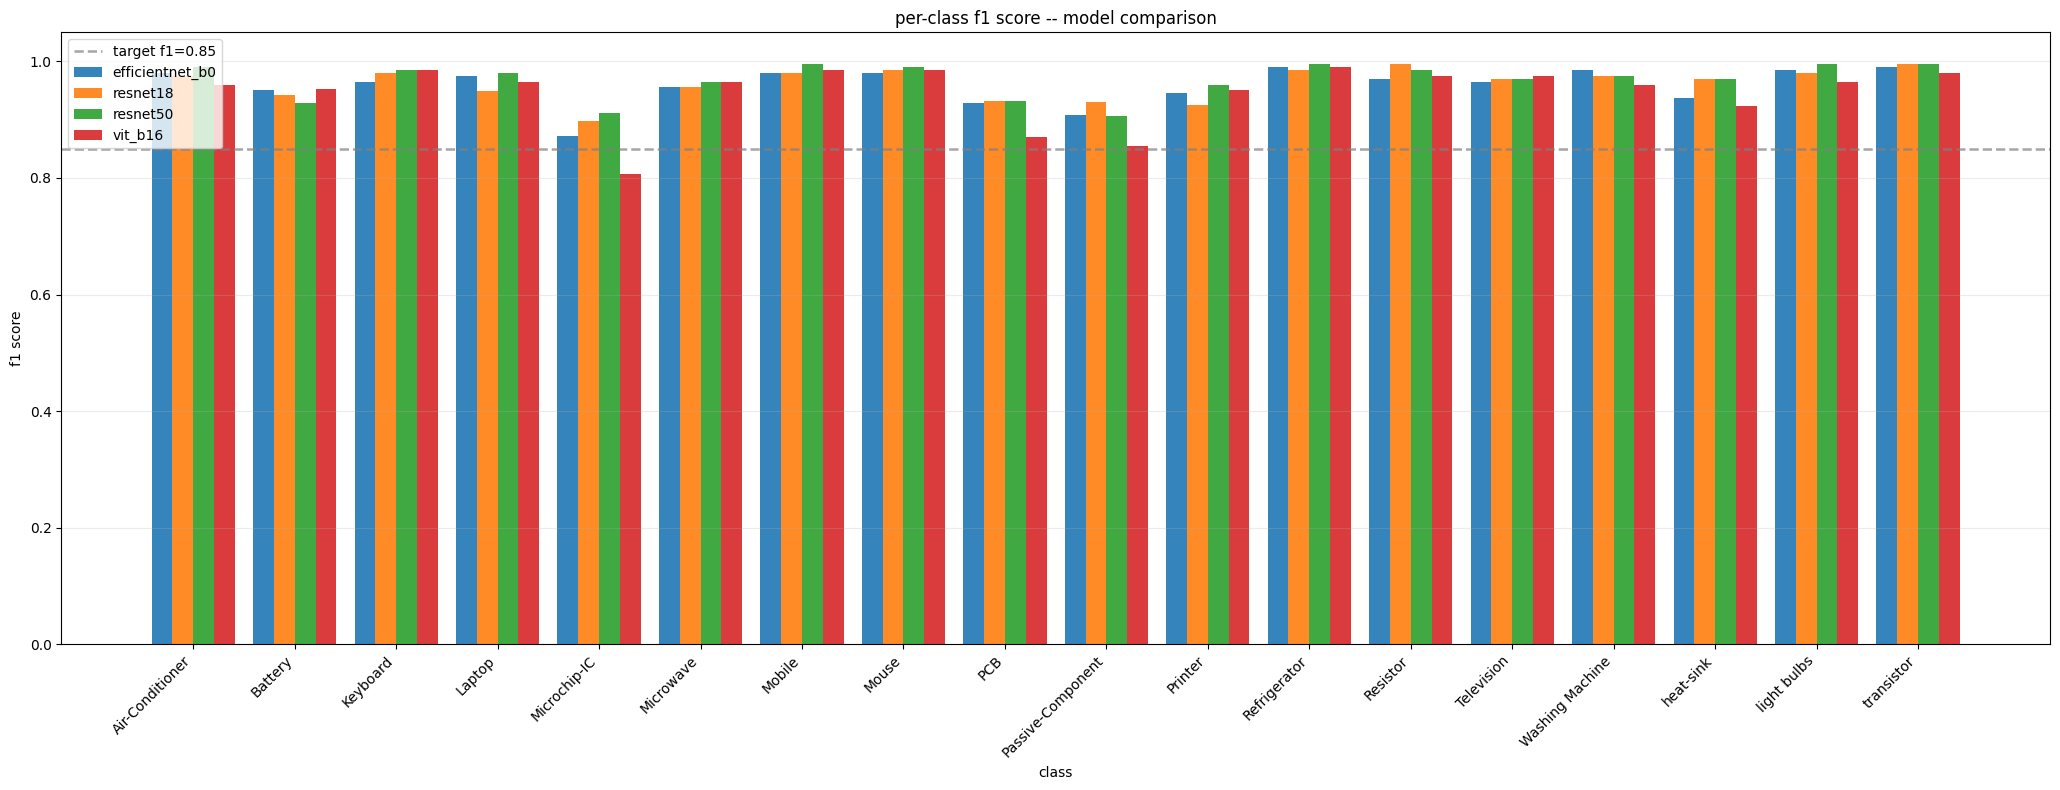

saved plot: D:\Github Desktop\ewaste_vit_project\models\classification\graphs\per_class_f1_comparison.png
saved scores: D:\Github Desktop\ewaste_vit_project\models\classification\per_class_f1_scores.json


In [4]:
# per-class f1 score -- model comparison (from saved checkpoints)
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score
from tqdm import tqdm

# -----------------------------
# paths and runtime
# -----------------------------
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "models").exists() and (PROJECT_ROOT / ".." / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

DATA_DIR = PROJECT_ROOT / "data"
CLS_DIR = PROJECT_ROOT / "models" / "classification"
OUT_DIR = CLS_DIR / "graphs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# -----------------------------
# helpers
# -----------------------------
SUPPORTED_ARCHES = [
    "resnet18",
    "resnet50",
    "efficientnet_b0",
    "efficientnet_b3",
    "convnext_tiny",
    "swin_tiny",
    "vit_b16",
]


def extract_state_dict(checkpoint_obj):
    if isinstance(checkpoint_obj, dict) and "model_state_dict" in checkpoint_obj:
        return checkpoint_obj["model_state_dict"]
    if isinstance(checkpoint_obj, dict) and "state_dict" in checkpoint_obj:
        return checkpoint_obj["state_dict"]
    if isinstance(checkpoint_obj, dict):
        return checkpoint_obj
    raise TypeError("unsupported checkpoint format")


def discover_checkpoints(classification_dir: Path):
    out = {}
    for arch in SUPPORTED_ARCHES:
        p1 = classification_dir / arch / f"{arch}_best.pth"
        p2 = classification_dir / f"{arch}_best.pth"
        if p1.exists():
            out[arch] = p1
        elif p2.exists():
            out[arch] = p2
    return out


def build_model_for_inference(arch: str, num_classes: int) -> nn.Module:
    if arch == "resnet18":
        model = models.resnet18(weights=None)
        in_dim = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    elif arch == "resnet50":
        model = models.resnet50(weights=None)
        in_dim = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    elif arch == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        in_dim = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    elif arch == "efficientnet_b3":
        model = models.efficientnet_b3(weights=None)
        in_dim = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
    elif arch == "convnext_tiny":
        model = models.convnext_tiny(weights=None)
        in_dim = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_dim, num_classes)
    elif arch == "swin_tiny":
        model = models.swin_t(weights=None)
        in_dim = model.head.in_features
        model.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_dim, num_classes))
    elif arch == "vit_b16":
        model = models.vit_b_16(weights=None)
        in_dim = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
    else:
        raise ValueError(f"unsupported arch: {arch}")
    return model


@torch.inference_mode()
def predict_labels(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in tqdm(loader, desc="eval", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_labels), np.concatenate(all_preds)


# -----------------------------
# data loader
# -----------------------------
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=eval_tf)
class_names = test_ds.classes
num_classes = len(class_names)
test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type == "cuda"),
)

# -----------------------------
# evaluate each saved model
# -----------------------------
checkpoints = discover_checkpoints(CLS_DIR)
if not checkpoints:
    raise FileNotFoundError(f"No checkpoints found under {CLS_DIR}")

print("found checkpoints:", sorted(checkpoints.keys()))
per_class_f1 = {}

for arch, ckpt_path in checkpoints.items():
    model = build_model_for_inference(arch, num_classes=num_classes).to(device)
    raw_ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(extract_state_dict(raw_ckpt))

    y_true, y_pred = predict_labels(model, test_loader, device)
    f1_by_class = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average=None,
        zero_division=0,
    )
    per_class_f1[arch] = f1_by_class
    print(f"{arch:<16} macro_f1={f1_by_class.mean():.4f}")

# -----------------------------
# plot grouped bar chart
# -----------------------------
model_names = sorted(per_class_f1.keys())
x = np.arange(num_classes)
bar_w = 0.82 / max(1, len(model_names))

plt.figure(figsize=(max(18, num_classes * 1.15), 8))
for i, arch in enumerate(model_names):
    y = per_class_f1[arch]
    offset = (i - (len(model_names) - 1) / 2.0) * bar_w
    plt.bar(x + offset, y, width=bar_w, label=arch, alpha=0.9)

plt.axhline(0.85, color="gray", linestyle="--", linewidth=1.8, alpha=0.7, label="target f1=0.85")
plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("f1 score")
plt.xlabel("class")
plt.title("per-class f1 score -- model comparison")
plt.legend(loc="upper left", frameon=True)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plot_path = OUT_DIR / "per_class_f1_comparison.png"
plt.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()

# save raw values for paper/report reuse
f1_json = {
    arch: {cls: float(score) for cls, score in zip(class_names, scores)}
    for arch, scores in per_class_f1.items()
}
with (CLS_DIR / "per_class_f1_scores.json").open("w", encoding="utf-8") as f:
    json.dump(f1_json, f, indent=2)

print(f"saved plot: {plot_path}")
print(f"saved scores: {CLS_DIR / 'per_class_f1_scores.json'}")